In [ ]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

feature_df = pd.read_pickle("/content/drive/MyDrive/SmartRail/features_full.pkl")
scaler2 = joblib.load("/content/drive/MyDrive/SmartRail/scaler2.pkl")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = feature_df.drop(columns=["failure"])
y = feature_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler2.transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Setup done")

Mounted at /content/drive
Setup done


In [ ]:
from sklearn.svm import SVC

sample_idx = np.random.choice(len(X_train_scaled), 30000, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.values[sample_idx]

svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_sample, y_train_sample)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_svm))
print(f"AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    285916
           1       0.76      0.99      0.86      5973

    accuracy                           0.99    291889
   macro avg       0.88      0.99      0.93    291889
weighted avg       0.99      0.99      0.99    291889

AUC: 0.9993


In [ ]:
joblib.dump(svm, "/content/drive/MyDrive/SmartRail/svm.pkl")

with open("/content/drive/MyDrive/SmartRail/results.json", "r") as f:
    results = json.load(f)

results["SVM"] = {"precision": 0.76, "recall": 0.99, "f1": 0.86, "auc": 0.9993}

with open("/content/drive/MyDrive/SmartRail/results.json", "w") as f:
    json.dump(results, f)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print(f"AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    285916
           1       0.86      1.00      0.92      5973

    accuracy                           1.00    291889
   macro avg       0.93      1.00      0.96    291889
weighted avg       1.00      1.00      1.00    291889

AUC: 0.9991


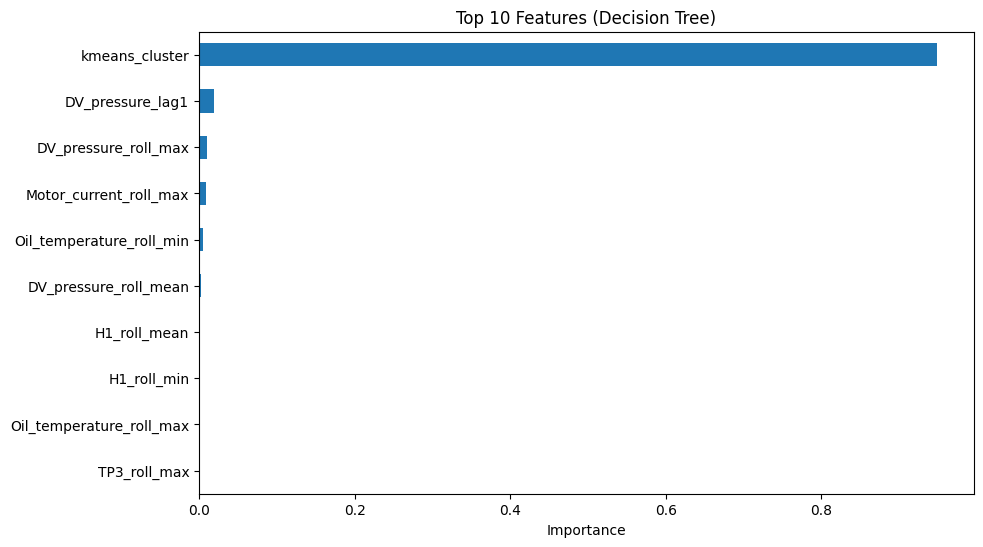

In [ ]:
importances = pd.Series(dt.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(10, 6))
plt.xlabel("Importance")
plt.title("Top 10 Features (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
joblib.dump(dt, "/content/drive/MyDrive/SmartRail/decision_tree.pkl")

with open("/content/drive/MyDrive/SmartRail/results.json", "r") as f:
    results = json.load(f)

results["Decision Tree"] = {"precision": 0.86, "recall": 1.00, "f1": 0.92, "auc": 0.9991}

with open("/content/drive/MyDrive/SmartRail/results.json", "w") as f:
    json.dump(results, f)